# Práctica 3: Visualización de los Datos

Para esta tercera práctica, se ejecuta código para generar gráficos que permitan la visualización de las diferentes variables.

## Librerías

Se importan las librerías necesarias para los gráficos.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Importación de los datos desde CSV

Se crea una copia del dataset limpio para manejarlo y realizar gráficos en esa copia.

In [3]:
# Se carga el conjunto de datos limpio.
df_original = pd.read_csv("C:\\Users\\Paty-\\OneDrive\\Documentos\\04 Facultad\\Séptimo Semestre\\Minería de Datos\\CardiovascularDiseaseDataMining\\Practica1\\cardiovascular_disease_cleaned.csv", sep=";")

# Se crea una copia del conjunto de datos limpio para trabajar en ella.
df = df_original.copy()

# Se muestran las primeras filas del conjunto de datos.
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,birth_date,age_scaled,height_scaled,weight_scaled,ap_hi_scaled,ap_lo_scaled
0,0,50,Male,168,62.0,110,80,Normal,Normal,No,No,Yes,No,1968-10-15 09:32:17.835072,-0.426244,0.477190,-0.911143,-1.149090,-0.221435
1,1,55,Female,156,85.0,140,90,Well Above Normal,Normal,No,No,Yes,Yes,1963-10-07 09:32:17.835072,0.315922,-1.116157,0.963057,0.950300,1.081779
2,2,51,Female,165,64.0,130,70,Well Above Normal,Normal,No,No,No,Yes,1967-07-09 09:32:17.835072,-0.277811,0.078853,-0.748169,0.250504,-1.524649
3,3,48,Male,169,82.0,150,100,Normal,Normal,No,No,Yes,Yes,1970-11-24 09:32:17.835072,-0.723111,0.609969,0.718596,1.650097,2.384993
4,8,59,Female,151,67.0,120,80,Above Normal,Above Normal,No,No,No,No,1959-02-24 09:32:17.835072,0.909656,-1.780052,-0.503708,-0.449293,-0.221435


## Diagrama de pastel para variables categóticas

Se generan diagramas de tipo pastel para las variables categóricas.

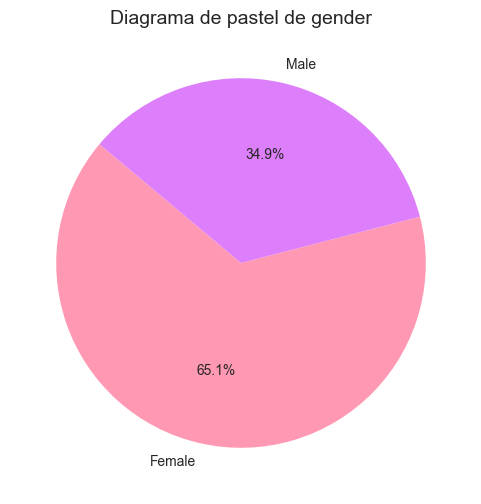

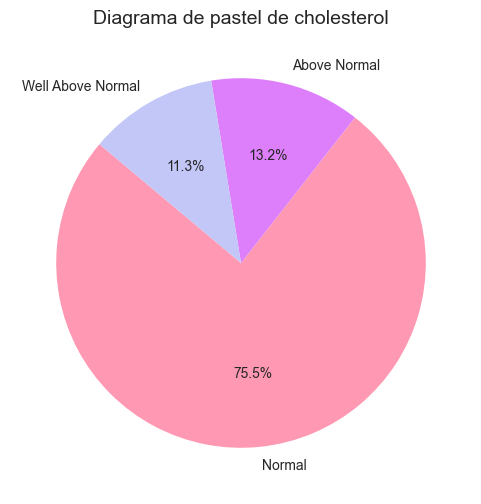

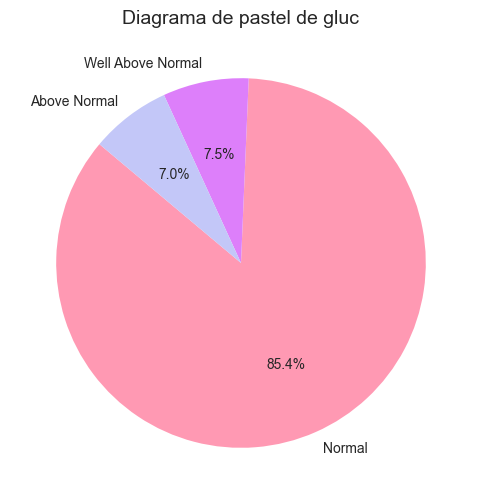

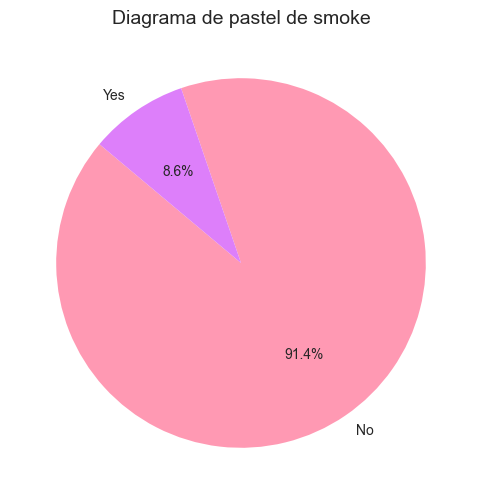

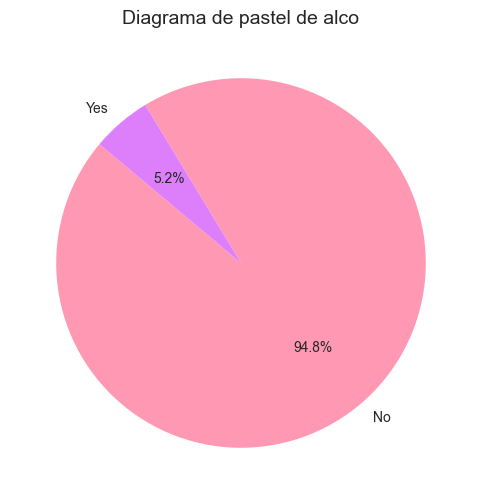

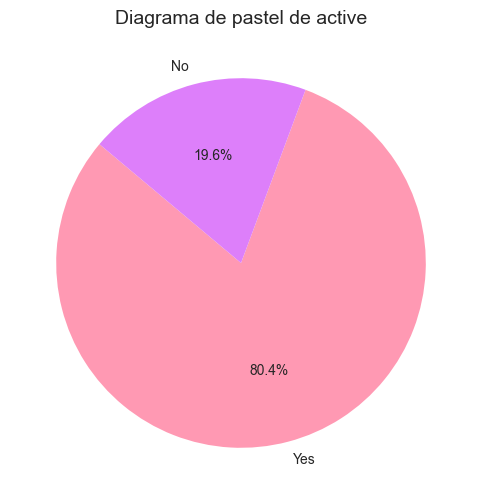

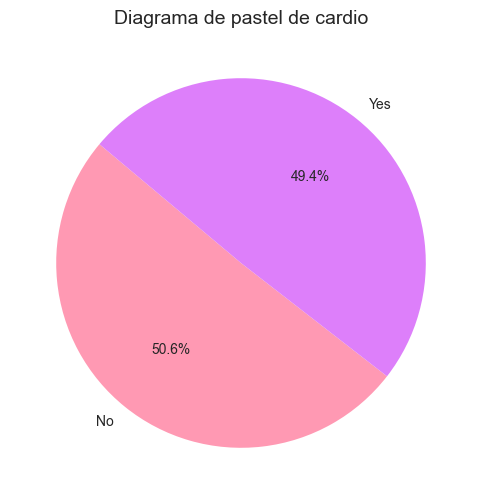

In [21]:
categorical_cols = ["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]

colors = ["#ff99b3", "#dd7ffa", "#c3c7f8"]

for col in categorical_cols:
    plt.figure(figsize=(6, 6))
    df[col].value_counts().plot.pie(
        autopct='%1.1f%%', 
        colors=colors, 
        startangle=140,
    )
    plt.title(f"Diagrama de pastel de {col}", fontsize=14)
    plt.ylabel("")
    plt.show()

## Histogramas para variables numéricas

Se generan diagramas de tipo histograma para las variables numéricas.

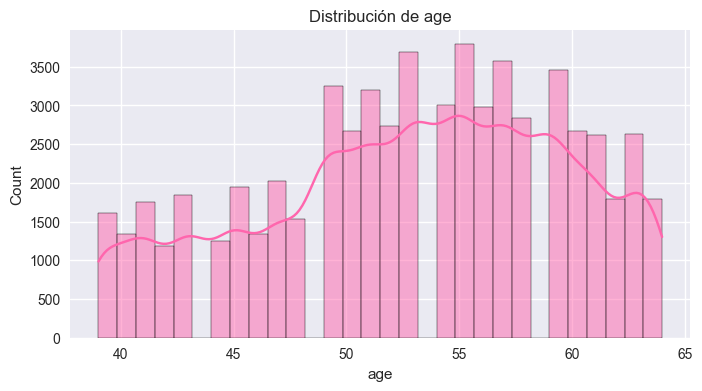

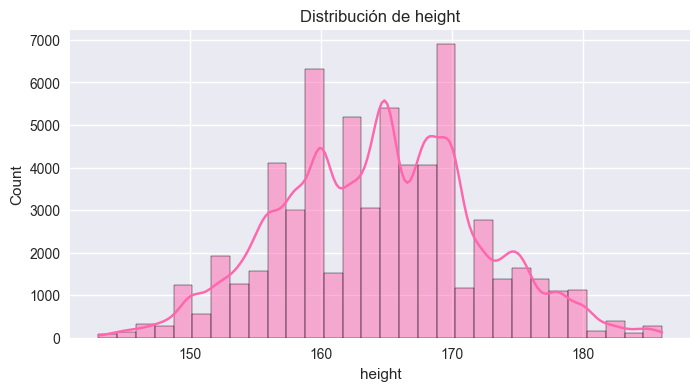

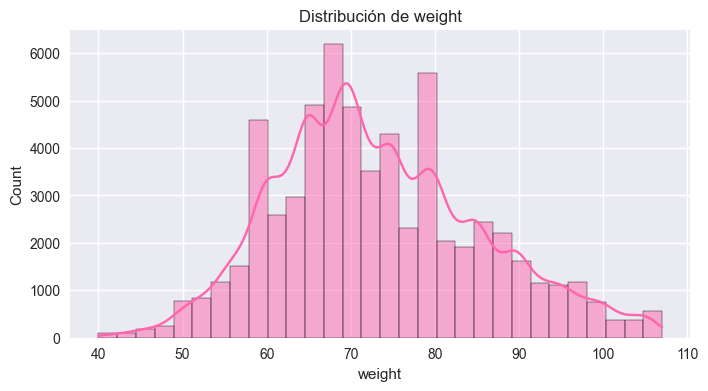

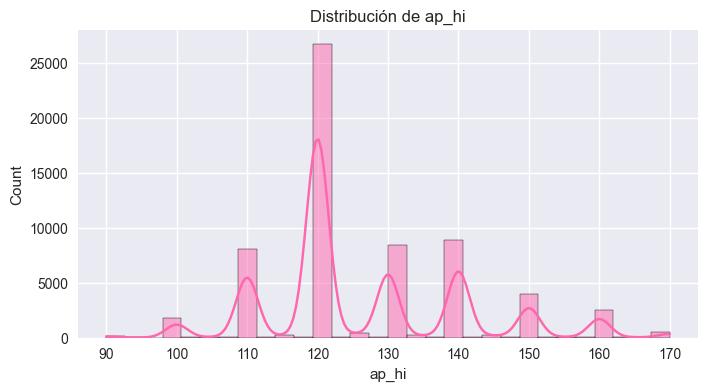

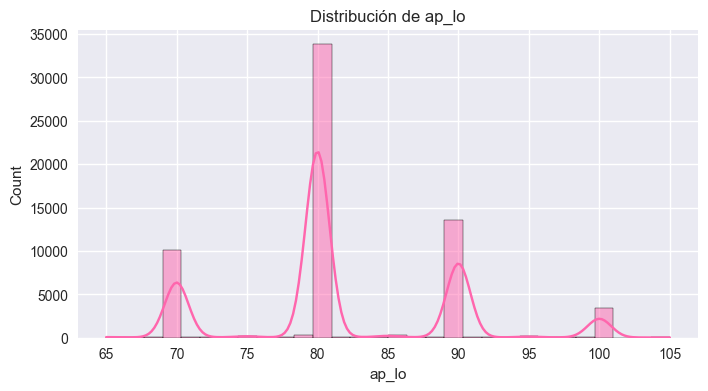

In [20]:
numeric_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, color="#ff66ad", kde=True) 
    plt.title(f"Distribución de {col}")
    plt.show()

## Boxplots para variables numéricas

Se generan diagramas de tipo boxplot para las variables numéricas.

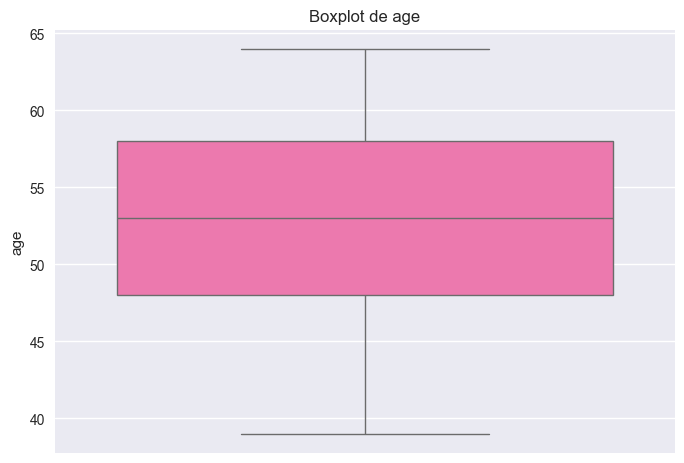

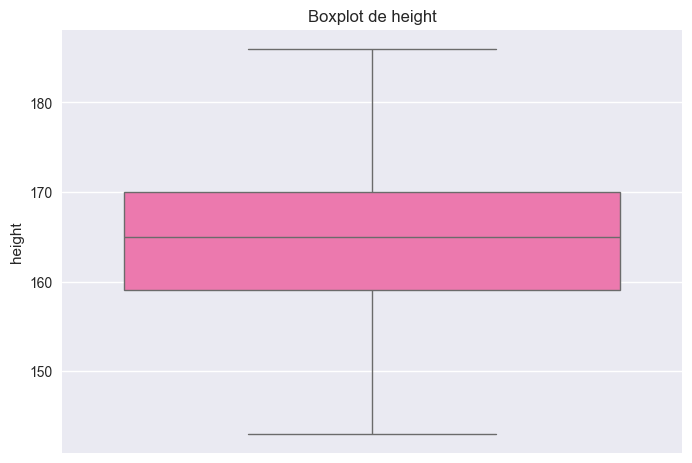

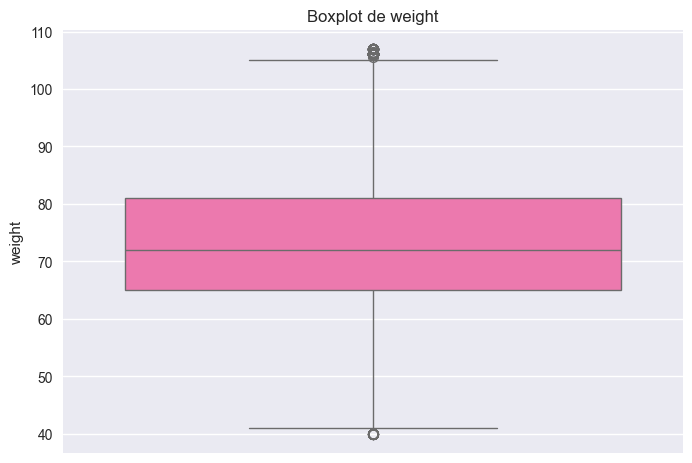

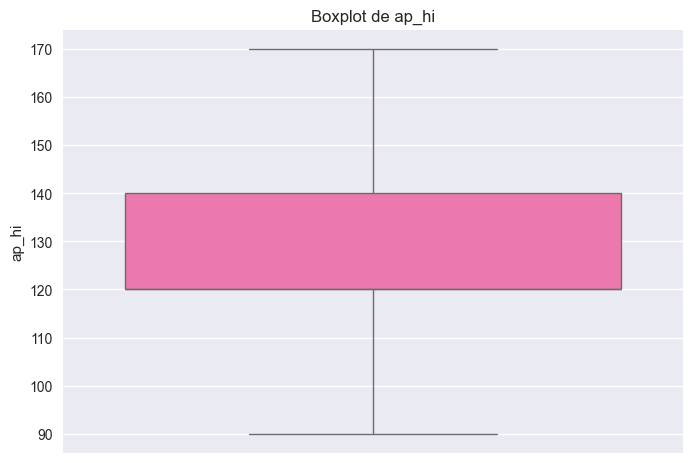

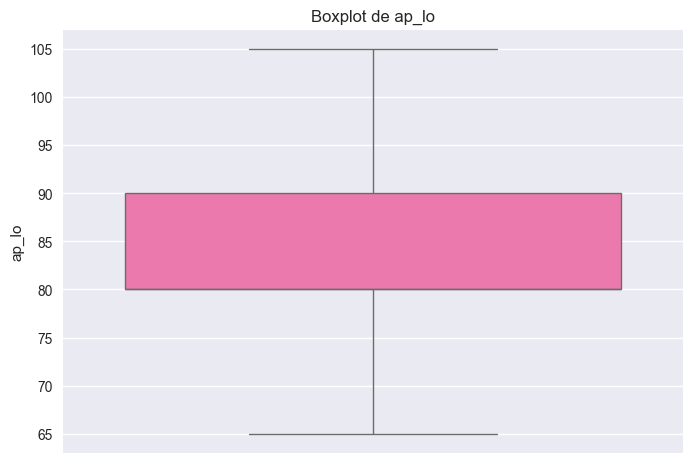

In [22]:
numeric_cols = ["age", "height", "weight", "ap_hi", "ap_lo"]

for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=df[col], color="#ff66ad")
    plt.title(f"Boxplot de {col}")
    plt.show()

## Scatter plots de relación con la variable cardio

Se generan diagramas de tipo scatter plot para las variables numéricas y su relación con la variable categórica cardio.

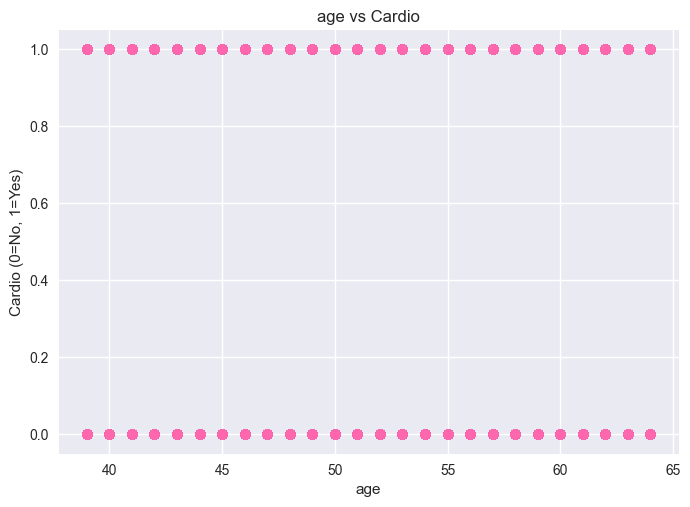

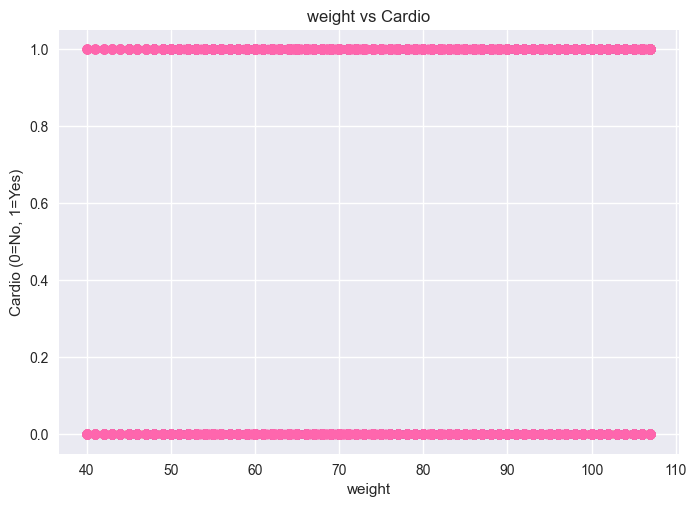

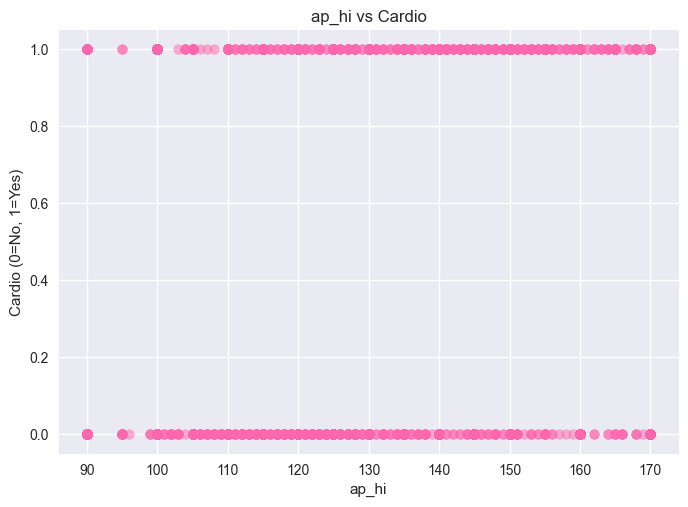

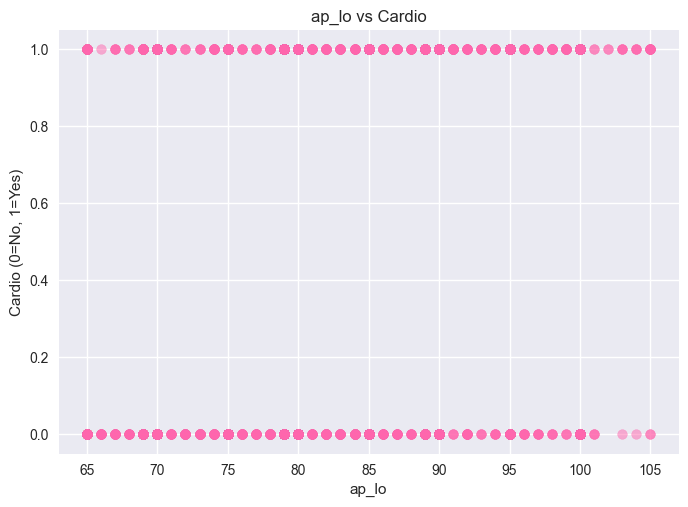

In [24]:
for col in ["age", "weight", "ap_hi", "ap_lo"]:
    plt.figure()
    plt.scatter(df[col], df["cardio"].map({"No":0, "Yes":1}), color="#ff66ad", alpha=0.5)
    plt.title(f"{col} vs Cardio")
    plt.xlabel(col)
    plt.ylabel("Cardio (0=No, 1=Yes)")
    plt.show()

## Line plot para la edad y la presión sistólica

Se generan un diagrama de tipo line plot para las variables.

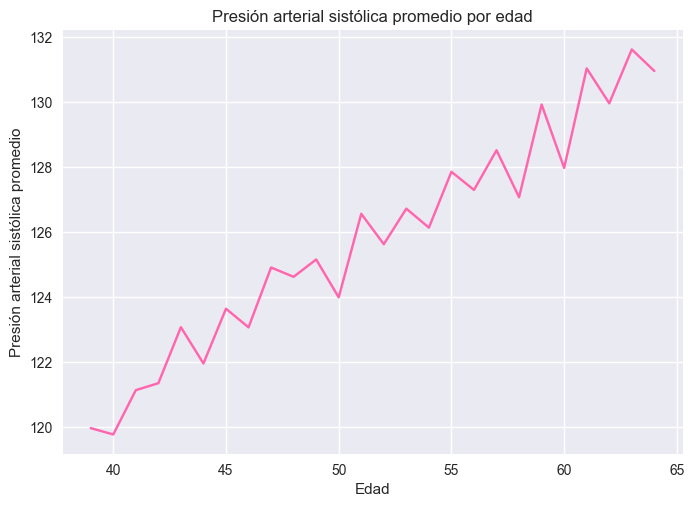

In [29]:
grouped = df.groupby("age")["ap_hi"].mean()

plt.figure()
plt.plot(grouped.index, grouped.values, color="#ff66ad")
plt.title("Presión arterial sistólica promedio por edad")
plt.xlabel("Edad")
plt.ylabel("Presión arterial sistólica promedio")
plt.show()

## Heatmap de correlación

Se genera un heatmap de correlación entre las columnas numéricas.

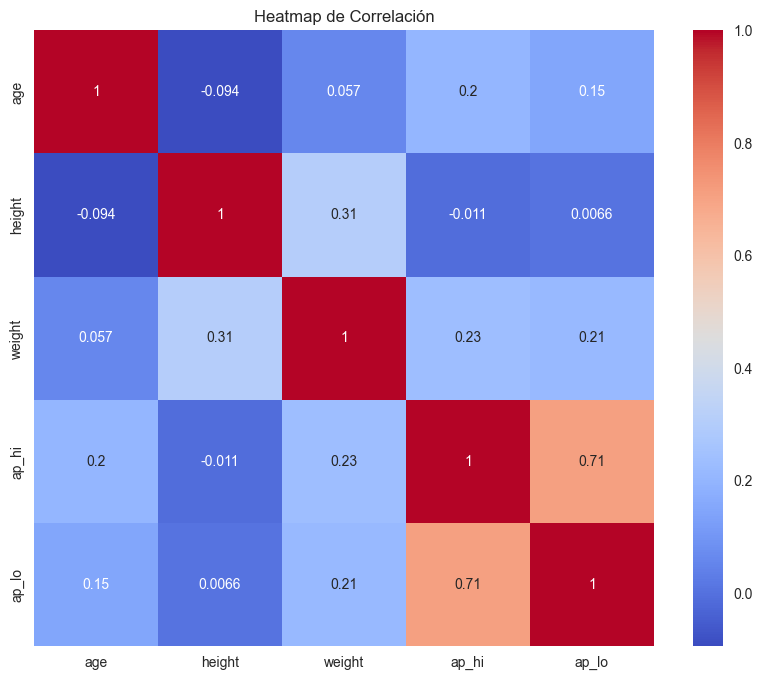

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap de Correlación")
plt.show()